In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

In [194]:
# EDIT THESE WITH SPECIFIC FUNCTIONALIZATION DATA
# MAKE SURE THESE ARE CORECT

folder_name = "2026-03-10 w1d04 dirac-tracking pyrene-capped pos-neg-ctrl/" # "2026-03-05 w1d14 dirac-tracking pyrene-capped pos-ctrl/"
folder_path = "../data_pcb_smu/" + folder_name

# Channels to include (0-based index after the time column)
channels_to_omit = [] # [12, 13, 14, 1, 11, 0, 10, 5] # [1, 11, 12, 14, 15, 0, 10, 13]
channels_to_plot = [i for i in range(15) if i not in channels_to_omit]
# [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15]
channel_colors = ['red', 'red', 'red', 'blue', 'red', 'red', 'green', 'blue', 'green', 'blue', 'blue', 'green', 'blue', 'green', 'green', 'green']

func_steps = ["Initial", "DDT", "Oligo"]

analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
# analyte_steps = ["1aM", "10aM", "100aM", "1fM", "10fM", "100fM", "1pM", "10pM", "100pM", "1nM", "10nM", "100nM", "1uM"]


func_title = "Functionalization Steps with Pyrene-capped Oligos"

analyte_title = "Dirac Shift with Pyrene-capped Oligos"


In [179]:
# Gathering files

func_files = []
analyte_files = []

print(f"Files in '{folder_name}' dir:", sorted(list(os.listdir(folder_path))))

for filename in sorted(list(os.listdir(folder_path))):
    if filename.split("-")[0][:7] == "analyte":
        analyte_files.append(filename)
    elif filename.split("-")[0][:4] == "func":
        func_files.append(filename)
    else:
        print("Skipped filename", filename)

print("Functionalization files (in order):", func_files)
print("Analyte files (in order):", analyte_files)

Files in '2026-03-10 w1d04 dirac-tracking pyrene-capped pos-neg-ctrl/' dir: ['.ipynb_checkpoints', 'analyte1-w1d04-1a.csv', 'analyte2-w1d04-100a.csv', 'analyte3-w1d04-10f.csv', 'analyte4-w1d04-1p.csv', 'analyte5-w1d04-100p.csv', 'analyte6-w1d04-10n.csv', 'analyte7-w1d04-1u.csv', 'func1-w1d04-id.csv', 'func2-w1d04-ddt.csv', 'func3-w1d04-oligo.csv', 'info.txt']
Skipped filename .ipynb_checkpoints
Skipped filename info.txt
Functionalization files (in order): ['func1-w1d04-id.csv', 'func2-w1d04-ddt.csv', 'func3-w1d04-oligo.csv']
Analyte files (in order): ['analyte1-w1d04-1a.csv', 'analyte2-w1d04-100a.csv', 'analyte3-w1d04-10f.csv', 'analyte4-w1d04-1p.csv', 'analyte5-w1d04-100p.csv', 'analyte6-w1d04-10n.csv', 'analyte7-w1d04-1u.csv']


FORWARD SWEEP


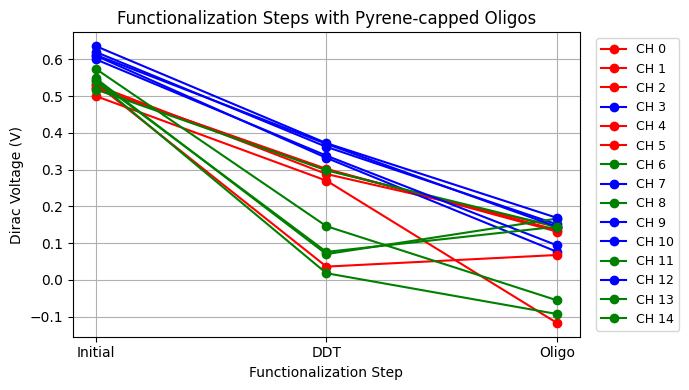

REVERSE SWEEP
['Initial', 'DDT', 'Oligo']


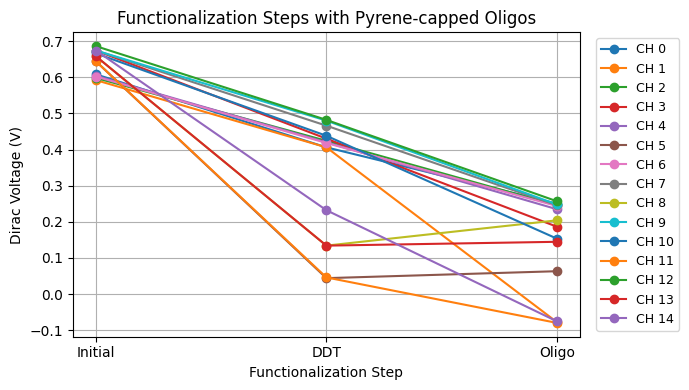

In [195]:
# plotting functionalizations

fwd_dps_func = np.zeros((len(func_files), len(channels_to_plot)))
rev_dps_func = np.zeros((len(func_files), len(channels_to_plot)))


for i, path in enumerate(func_files):
    # Load the data (adjust filename)
    df = pd.read_csv(folder_path + path)
    
    # Identify rows that contain Dirac data (DIRAC_SWEEP_IDX is not NaN)
    dirac_rows = df[df["DIRAC_SWEEP_IDX"].notna()].copy()
    
    # Use time from previous row (n-1)
    dirac_rows["TIME_FROM_PREV"] = df["TIME"].shift(1).loc[dirac_rows.index].values
    
    # Collect Dirac voltages for all 16 channels
    channel_cols_to_get_fwd = [f"DIRAC_V_FWD_CH{i}" for i in range(16)]
    channel_cols_to_get_rev = [f"DIRAC_V_REV_CH{i}" for i in range(16)]

    for j, ch in enumerate(channels_to_plot):
        dirac_vals_fwd = list(dirac_rows[channel_cols_to_get_fwd[ch]])
        dirac_vals_rev = list(dirac_rows[channel_cols_to_get_rev[ch]])
        fwd_dps_func[i, j] = dirac_vals_fwd[-1]
        rev_dps_func[i, j] = dirac_vals_rev[-1]


n_rows, n_cols = fwd_dps_func.shape
x = np.arange(n_rows)

# for forward sweep
print("FORWARD SWEEP")
plt.figure(figsize=(7, 4))
for col in range(n_cols):
    ch = channels_to_plot[col]
    plt.plot(x, fwd_dps_func[:, col], marker='o', label=f'CH {ch}', color = channel_colors[ch])
plt.xlabel("Functionalization Step")
plt.ylabel("Dirac Voltage (V)")
plt.xticks(x, func_steps[:len(func_files)])
plt.grid(True)
plt.legend(ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title(func_title)
plt.tight_layout()
plt.show()
plt.close()

# for reverse sweep
print("REVERSE SWEEP")
plt.figure(figsize=(7, 4))
for col in range(n_cols):
    plt.plot(x, rev_dps_func[:, col], marker='o', label=f'CH {channels_to_plot[col]}')
plt.xlabel("Functionalization Step")
plt.ylabel("Dirac Voltage (V)")
print(func_steps)
plt.xticks(x, func_steps[:len(func_files)])
plt.grid(True)
plt.legend(ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title(func_title)
plt.tight_layout()
plt.show()
plt.close()

FORWARD SWEEP, ABSOLUTE VALUE


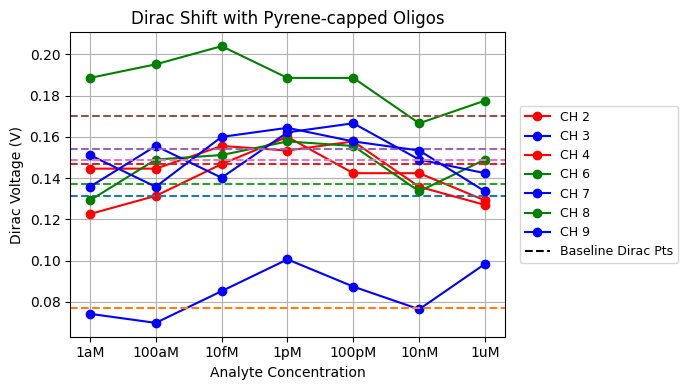

FORWARD SWEEP, NORMALIZED VALUE


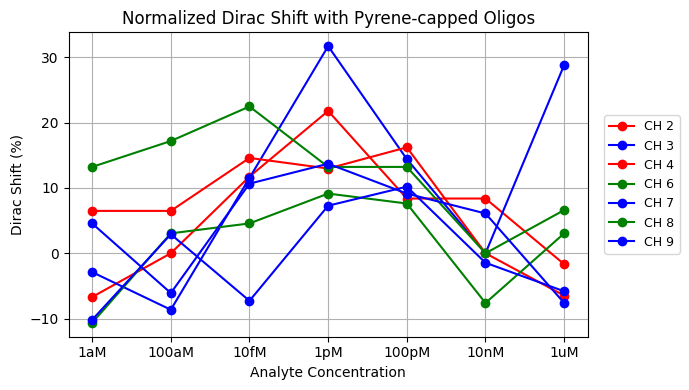

REVERSE SWEEP, ABSOLUTE VALUE


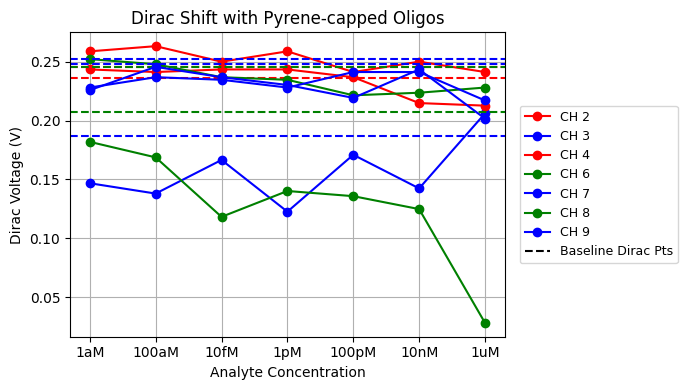

REVERSE SWEEP, NORMALIZED VALUE


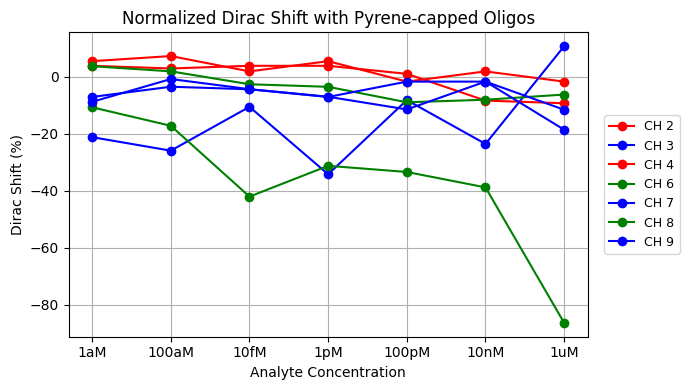

In [193]:
# plottig analyte shifts

fwd_dps_analyte = np.zeros((len(analyte_files), len(channels_to_plot)))
rev_dps_analyte = np.zeros((len(analyte_files), len(channels_to_plot)))

for i, path in enumerate(analyte_files):
    # Load the data (adjust filename)
    df = pd.read_csv(folder_path + path)
    
    # Identify rows that contain Dirac data (DIRAC_SWEEP_IDX is not NaN)
    dirac_rows = df[df["DIRAC_SWEEP_IDX"].notna()].copy()
    
    # Use time from previous row (n-1)
    dirac_rows["TIME_FROM_PREV"] = df["TIME"].shift(1).loc[dirac_rows.index].values
    
    # Collect Dirac voltages for all 16 channels
    channe_cols_to_get_fwd = [f"DIRAC_V_FWD_CH{i}" for i in range(16)]
    channe_cols_to_get_rev = [f"DIRAC_V_REV_CH{i}" for i in range(16)]

    for j, ch in enumerate(channels_to_plot):
        dirac_vals_fwd = list(dirac_rows[channel_cols_to_get_fwd[ch]])
        dirac_vals_rev = list(dirac_rows[channel_cols_to_get_rev[ch]])
        fwd_dps_analyte[i, j] = dirac_vals_fwd[-1]
        rev_dps_analyte[i, j] = dirac_vals_rev[-1]




# baseline dirac voltage, based on post-oligo measurement (last functionalization step)
baseline_file = func_files[-1]  # last string in the func list
df_baseline = pd.read_csv(folder_path + baseline_file)

# Identify Dirac rows in baseline
dirac_rows_base = df_baseline[df_baseline["DIRAC_SWEEP_IDX"].notna()].copy()

# Collect baseline dirac voltages for channels to plot
channel_cols_baseline_fwd = [f"DIRAC_V_FWD_CH{i}" for i in range(16)]
channel_cols_baseline_rev = [f"DIRAC_V_REV_CH{i}" for i in range(16)]
baseline_vals_fwd = []
baseline_vals_rev = []
for ch in channels_to_plot:
    dirac_vals_ch_fwd = dirac_rows_base[channel_cols_baseline_fwd[ch]].to_numpy()
    dirac_vals_ch_rev = dirac_rows_base[channel_cols_baseline_rev[ch]].to_numpy()
    baseline_vals_fwd.append(dirac_vals_ch_fwd[-1])
    baseline_vals_rev.append(dirac_vals_ch_rev[-1])
baseline_vals_fwd = np.array(baseline_vals_fwd)
baseline_vals_rev = np.array(baseline_vals_rev)

# compute normalized plots
norm_fwd_dps_analyte = (fwd_dps_analyte - baseline_vals_fwd) / baseline_vals_fwd * 100
norm_rev_dps_analyte = (rev_dps_analyte - baseline_vals_rev) / baseline_vals_rev * 100



n_rows, n_cols = fwd_dps_analyte.shape
x = np.arange(n_rows)





# forward sweep plot, absolute value
print("FORWARD SWEEP, ABSOLUTE VALUE")
plt.figure(figsize=(7, 4))
for col in range(n_cols):
    ch = channels_to_plot[col]
    plt.plot(x, fwd_dps_analyte[:, col], marker='o', label=f'CH {ch}', color=channel_colors[ch])

    plt.axhline(
        y=baseline_vals_fwd[col] + col * 7e-4, # tiny vertical offset (tune to your voltage scale)
        color=f"C{col}",
        linestyle="--"
    )
plt.xlabel("Analyte Concentration")
plt.ylabel("Dirac Voltage (V)")
plt.xticks(x, analyte_steps[:len(analyte_files)])
plt.grid(True)
baseline_line = Line2D([0], [0], color='black', linestyle='--', label='Baseline Dirac Pts')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles + [baseline_line], ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title(analyte_title)
plt.tight_layout()
plt.show()
plt.close()



# forward sweep plot, normalized value
print("FORWARD SWEEP, NORMALIZED VALUE")
plt.figure(figsize=(7, 4))
for col in range(n_cols):
    ch = channels_to_plot[col]
    plt.plot(x, norm_fwd_dps_analyte[:, col], marker='o', label=f'CH {ch}', color=channel_colors[ch])

plt.xlabel("Analyte Concentration")
plt.ylabel("Dirac Shift (%)")
plt.xticks(x, analyte_steps[:len(analyte_files)])
plt.grid(True)
plt.legend(ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title("Normalized " + analyte_title)
plt.tight_layout()
plt.show()
plt.close()



# reverse sweep plot, absolute value
print("REVERSE SWEEP, ABSOLUTE VALUE")
plt.figure(figsize=(7, 4))
for col in range(n_cols):
    ch = channels_to_plot[col]
    plt.plot(x, rev_dps_analyte[:, col], marker='o', label=f'CH {ch}', color=channel_colors[ch])

    plt.axhline(
        y=baseline_vals_rev[col] + col * 7e-4, # tiny vertical offset (tune to your voltage scale)
        color= channel_colors[ch], # f"C{col}",
        linestyle="--"
    )
plt.xlabel("Analyte Concentration")
plt.ylabel("Dirac Voltage (V)")
plt.xticks(x, analyte_steps[:len(analyte_files)])
plt.grid(True)
baseline_line = Line2D([0], [0], color='black', linestyle='--', label='Baseline Dirac Pts')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles + [baseline_line], ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title(analyte_title)
plt.tight_layout()
plt.show()
plt.close()



# forward plot, normalized value
print("REVERSE SWEEP, NORMALIZED VALUE")
plt.figure(figsize=(7, 4))
for col in range(n_cols):
    ch = channels_to_plot[col]
    plt.plot(x, norm_rev_dps_analyte[:, col], marker='o', label=f'CH {ch}', color=channel_colors[ch])

plt.xlabel("Analyte Concentration")
plt.ylabel("Dirac Shift (%)")
plt.xticks(x, analyte_steps[:len(analyte_files)])
plt.grid(True)
plt.legend(ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title("Normalized " + analyte_title)
plt.tight_layout()
plt.show()
plt.close()

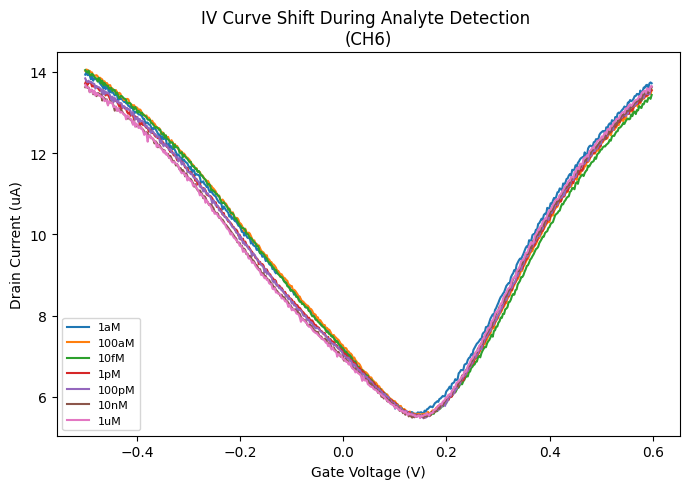

In [176]:
channel_to_plot = 6

plt.figure(figsize=(7, 5))

for i, path in enumerate(analyte_files):
    df = pd.read_csv(folder_path + path)

    last_full_sweep_idx = int(df["SWEEP_IDX"].iloc[-1] - 1)

    cols = ["V_GATE", f"I_CH{channel_to_plot}"]
    subset = df.loc[df["SWEEP_IDX"] == last_full_sweep_idx, cols]
    n = len(subset)
    subset = subset[:n//2]


    plt.plot(
        subset["V_GATE"].to_numpy(),
        subset[f"I_CH{channel_to_plot}"].to_numpy() * 1e6,
        # marker="o",
        label=path.split('-')[-1].split('.')[-2]+"M"
    )

plt.xlabel("Gate Voltage (V)")
plt.ylabel("Drain Current (uA)")
plt.title(f"IV Curve Shift During Analyte Detection \n(CH{channel_to_plot})")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

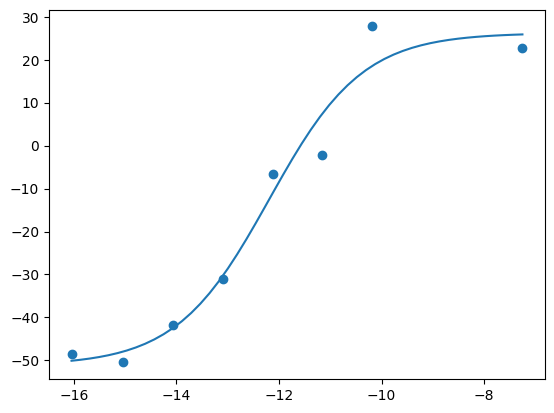

In [166]:
# hill curve fitting


def hill_function(x, A, K, n, b):
    '''
    Hill curve
    Returns the value at input x, given coefficients
    '''    
    return A * (x**n) / (K**n + x**n) + b

def hill_log_function(x_log, A, logK, n, b):
    return A / (1 + 10**((logK - x_log)*n)) + b


x_data=np.array([9.01e-17, 9.24e-16, 8.62e-15, 8.00e-14, 7.47e-13, 7.00e-12, 6.58e-11, 5.56e-08])
x_data_log = np.log10(x_data)
y_data=np.array([-48.47129542, -50.49397118, -41.70719857, -31.0603037 , -6.62752382,  -2.24790406,  27.73919795,  22.81455124])
# y_data=[19.84854715, 27.80136539, 37.33263036, 44.36770214, 48.95835796, 53.67856878, 55.78135487, 59.19859929]



bounds = (
    [0, -20, 0, -100],
    [200, 0, 5, 100]
)
hill_coeffs_log, _ = curve_fit(
    hill_log_function,
    x_data_log,
    y_data,
    bounds=bounds,
    method='trf'
)
X_fit = np.linspace(min(x_data_log), max(x_data_log), 50)
Y_fit = hill_log_function(X_fit, *hill_coeffs_log)
plt.plot(X_fit, Y_fit)
plt.scatter(x_data_log, y_data)
plt.show()
plt.close()


C:\Users\joeyl\AppData\Local\Temp\ipykernel_71232\499796657.py:2: RuntimeWarning: invalid value encountered in scalar power
  return A * (x**n) / (K**n + x**n) + b


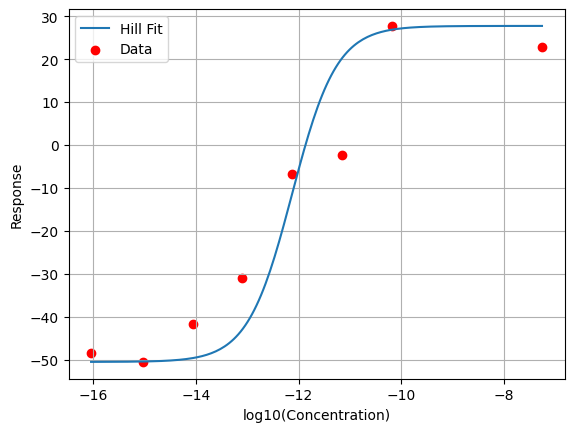

In [167]:
def hill_function(x, A, K, n, b):
    return A * (x**n) / (K**n + x**n) + b

# Your data
x_data_log = np.array([-16.045, -15.034, -14.064, -13.096, -12.126, -11.154, -10.182, -7.255])
y_data = np.array([-48.471, -50.494, -41.707, -31.060, -6.628, -2.248, 27.739, 22.815])

x_data = 10**x_data_log  # convert to linear

bounds = (
    [0, 1e-18, 0, -100],  # lower
    [200, 1e-5, 5, 100]   # upper
)

# initial_guess = [75, 2e-13, 1, -50]

b0 = np.min(y_data)
A0 = np.max(y_data) - b0
y_half = b0 + A0 / 2

# Find closest point in y_data to half-max
idx = np.argmin(np.abs(y_data - y_half))
K0 = x_data[idx]  # corresponding linear concentration
n0 = 1

initial_guess = [A0, K0, n0, b0]

# Fit in linear space
hill_coeffs, _ = curve_fit(
    hill_function,
    x_data,
    y_data,
    # bounds=bounds,
    p0=initial_guess,
    method='trf'
)

# Generate smooth curve for plotting
X_fit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 200)
Y_fit = hill_function(X_fit, *hill_coeffs)

# Plot using log10 x-axis
plt.plot(np.log10(X_fit), Y_fit, label='Hill Fit')
plt.scatter(x_data_log, y_data, color='red', label='Data')
plt.xlabel("log10(Concentration)")
plt.ylabel("Response")
plt.legend()
plt.grid(True)
plt.show()
plt.close()

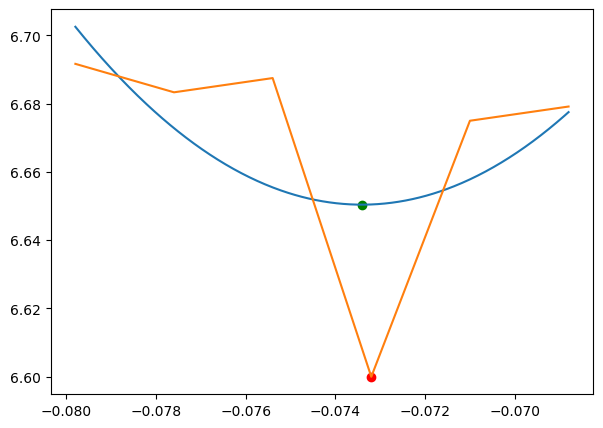

In [168]:
# this tries to smooth out the dirac region then tahe the min for the dirac point using the smoothed plot
# this does not work very well... the fit is not great. Can try for higher order polynomials or another form...


channel_to_plot = 1
plt.figure(figsize=(7, 5))
df = pd.read_csv(folder_path + analyte_files[0])
last_full_sweep_idx = int(df["SWEEP_IDX"].iloc[-1] - 1)
cols = ["V_GATE", f"I_CH{channel_to_plot}"]
subset = df.loc[df["SWEEP_IDX"] == last_full_sweep_idx, cols]
n = len(subset)
subset = subset[:n//2]
x = subset["V_GATE"].to_numpy()
y = subset[f"I_CH{channel_to_plot}"].to_numpy() * 1e6

argmin_x = np.argmin(y)

region_buffer = 3
dirac_region_x = x[argmin_x-region_buffer:argmin_x+region_buffer]
dirac_region_y = y[argmin_x-region_buffer:argmin_x+region_buffer]


coeffs = np.polyfit(dirac_region_x, dirac_region_y, 2)
a, b, c = coeffs
p = np.poly1d(coeffs)



x_min = -b / (2*a)
y_min = p(x_min)

x_fit = np.linspace(min(dirac_region_x), max(dirac_region_x), 500)
y_fit = p(x_fit)
plt.plot(x_fit, y_fit)



plt.plot(dirac_region_x, dirac_region_y)
plt.scatter(x[argmin_x], y[argmin_x], color='red')
plt.scatter(x_min, y_min, color='green')

plt.show()
plt.close()


